# IBD Study

In [1]:
import re
import numpy as np
import pandas as pd
import random
import seaborn as sns
import scipy.stats as stats
import torch
import biom
import matplotlib_venn
from metvae.model import MetVAE

import matplotlib.pyplot as plt
%matplotlib inline

## Data Import

In [2]:
# The biom table
table = biom.load_table('../data/ibd/HMP2_metabolomics_w_metadata.biom')
sample_ids = table.ids(axis='sample')
observation_ids = table.ids(axis='observation')

In [3]:
# The abundance data
abundance_raw = table.matrix_data.toarray()
abundance_raw = pd.DataFrame(abundance_raw,
                             index=observation_ids,
                             columns=sample_ids)
abundance_raw.head()

,HSM5FZBJ,MSM5FZ9X,CSM5FZ3N,ESM5MEDZ,MSM5FZA2,MSM5LLHZ,HSM5FZBQ,MSM5LLIC,MSM5LLIG,CSM5FZ3T,...,MSMB4LZC,MSMB4LZR,MSMB4LZ8,HSMA33SK,MSMB4LYH,PSMB4MC5,HSMA33RX,HSMA33RL,MSMB4LYB,MSMB4LZK
C18n_QI06,4355470.0,2623839.0,942546.0,5759125.0,2231416.0,913814.0,1976143.0,2322948.0,1355598.0,470132.0,...,2286333.0,384886.0,920518.0,295487.0,1009373.0,2421531.0,1685079.0,2054717.0,1655387.0,1982374.0
C18n_QI07,1512589.0,2299190.0,1418451.0,3515867.0,1589344.0,1208032.0,2623311.0,2388903.0,950988.0,416924.0,...,1957142.0,313876.0,1145722.0,270803.0,974763.0,1000980.0,1536293.0,1337477.0,1649427.0,1170889.0
C18n_QI08,9636.0,100.0,2194.0,161.0,962.0,300.0,6403.0,51832.0,842.0,28.0,...,2316.0,186.0,1476.0,42577.0,20963.0,272.0,14318.0,209334.0,5727.0,319.0
C18n_QI09,0.0,0.0,0.0,0.0,0.0,0.0,39.0,12009.0,0.0,0.0,...,75.0,0.0,0.0,36838.0,15718.0,0.0,25.0,4427.0,35.0,0.0
C18n_QI10,40871.0,8382.0,38180.0,58551.0,5542.0,393533.0,42885.0,925552.0,238347.0,11781.0,...,382013.0,21418.0,1722039.0,113509.0,583775.0,28097.0,15229.0,1496165.0,73931.0,6530.0


In [4]:
# the feature metadata 
fmd_raw = [table.metadata(id=obs_id, axis='observation') for obs_id in observation_ids]
fmd_raw = pd.DataFrame(fmd_raw)
fmd_raw.set_index(observation_ids, inplace=True)
fmd_raw.head()

,RT,m/z,Metabolite,HMDB (*Representative ID),Pooled QC sample CV,Method
C18n_QI06,9.75,313.2387,12.13-diHOME,HMDB04705,0.027194334,C18-neg
C18n_QI07,9.95,313.2387,9.10-diHOME,HMDB04704,0.026412656,C18-neg
C18n_QI08,5.79,115.0752,caproate,HMDB00535,0.046835889,C18-neg
C18n_QI09,7.43,129.0909,heptanoate,HMDB00666,0.074082919,C18-neg
C18n_QI10,5.81,149.0597,hydrocinnamate,HMDB00764,0.024137633,C18-neg


In [5]:
# the sample metadata
smd_raw = pd.read_csv('../data/ibd/hmp2_metadata_2018-08-20.csv')
smd_raw.head()

/var/folders/rn/10vtwtd944j73gfdxc_pbl680000gr/T/ipykernel_91512/2556009309.py:2: DtypeWarning: Columns (12,13,14,40,46,55,65,66,67,68,177,294,298,299,300,301,304,305,306,307,308,309,310,318,320,328,330,346,348,350,352,354,359,361,363,366,373,377,381,383,418,419,432,433,434,435,436,438,439,440,441,442,444,445,446,447,448,450,451,452,453,454) have mixed types. Specify dtype option on import or set low_memory=False.
  smd_raw = pd.read_csv('../data/ibd/hmp2_metadata_2018-08-20.csv')


,Project,External ID,Participant ID,site_sub_coll,data_type,week_num,date_of_receipt,interval_days,visit_num,Research Project,...,FecalCal received at MGH:,Proteomics received at LBNL:,Stool Sample ID: Tube A (EtOH),Sample ID: Tube B (No preservative),Tube A and B received at Broad:,stool_id,smoking status,Number years smoked,Age when started smoking,How many cigarettes/cigars/etc. do you smoke per day?
0,C3001CSC1_BP,206615,C3001,C3001CSC1,biopsy_16S,2.0,NaN,NaN,1,ibdmdb,...,No,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
1,C3001CSC2_BP,206614,C3001,C3001CSC2,biopsy_16S,2.0,NaN,NaN,1,ibdmdb,...,No,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
2,C3002CSC1_BP,206617,C3002,C3002CSC1,biopsy_16S,0.0,NaN,NaN,1,ibdmdb,...,No,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
3,C3002CSC2_BP,206619,C3002,C3002CSC2,biopsy_16S,0.0,NaN,NaN,1,ibdmdb,...,No,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
4,C3002CSC3_BP,206616,C3002,C3002CSC3,biopsy_16S,0.0,NaN,NaN,1,ibdmdb,...,No,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN


In [6]:
print('Raw abundance data shape: ', abundance_raw.shape)
print('Raw feature metadata shape: ', fmd_raw.shape)
print('Raw sample metadata shape: ', smd_raw.shape)

Raw abundance data shape:  (81867, 546)
Raw feature metadata shape:  (81867, 6)
Raw sample metadata shape:  (5533, 490)


## Data Cleaning

In [7]:
def convert_hmdb(x):
    """
    Convert HMDB string by removing '*' and adding '00' after 'HMDB'.
    """
    if not isinstance(x, str) or x.strip() in ["", "NA"]:
        return np.nan

    # Remove '*' characters
    x = re.sub(r"\*", "", x)
    # Add '00' after 'HMDB'
    x = re.sub(r"HMDB(\d+)", r"HMDB00\1", x)
    return x

def filled(s: pd.Series) -> pd.Series:
    # True only if not NaN and not empty/whitespace
    return s.notna() & s.astype(str).str.strip().ne('')

In [8]:
# Keep only annotated features
keep = (
    (fmd_raw['HMDB (*Representative ID)'] != 'redundant ion') &
    (filled(fmd_raw['Metabolite']) | filled(fmd_raw['HMDB (*Representative ID)']))
)

fmd = fmd_raw.loc[keep].copy()

# Convert HMDB IDs
fmd['HMDB'] = fmd['HMDB (*Representative ID)'].apply(convert_hmdb)

# For duplicated metabolites, keep the one with the lowest pooled QC sample CV
fmd.sort_values(by=['Metabolite', 'Pooled QC sample CV'], ascending=[True, True], inplace=True)
fmd.drop_duplicates(subset='Metabolite', keep='first', inplace=True)

# Select only metabolomics samples, on baseline visit, and with IBD
smd = smd_raw[(smd_raw['data_type'] == 'metabolomics') & (smd_raw['visit_num'] == 4)].copy()
smd = smd.set_index('External ID', drop=True)

# Subset the abundance data
abundance_data = abundance_raw.loc[abundance_raw.index.isin(fmd.index), abundance_raw.columns.isin(smd.index)].copy()

In [9]:
print('Abundance data shape: ', abundance_data.shape)
print('Feature metadata shape: ', fmd.shape)
print('Sample metadata shape: ', smd.shape)

Abundance data shape:  (477, 70)
Feature metadata shape:  (477, 7)
Sample metadata shape:  (70, 489)


### Outcomes of interest

In [10]:
smd['diagnosis'].value_counts()

diagnosis
CD        31
UC        20
nonIBD    19
Name: count, dtype: int64

### Covariates/confounders

In [11]:
smd[['Antibiotics']]

,Antibiotics
External ID,
CSM5FZ3N,No
CSM5FZ3T,No
CSM5FZ48,Yes
CSM5FZ4A,No
CSM5FZ4O,No
...,...
PSM6XBQM,No
PSM6XBRK,No
PSM6XBSE,No


In [12]:
smd.rename(columns={'Antibiotics': 'abx'}, inplace=True)
smd['abx'].value_counts()

abx
No     61
Yes     9
Name: count, dtype: int64

In [13]:
smd['sex'].value_counts()

sex
Female    41
Male      29
Name: count, dtype: int64

In [14]:
smd.rename(columns={'consent_age': 'age'}, inplace=True)
smd[['age']].describe()

,age
count,70.000000
mean,30.428571
std,18.692455
min,6.000000
25%,14.250000
50%,27.000000
75%,43.750000
max,76.000000


## Exploratory Data Analysis

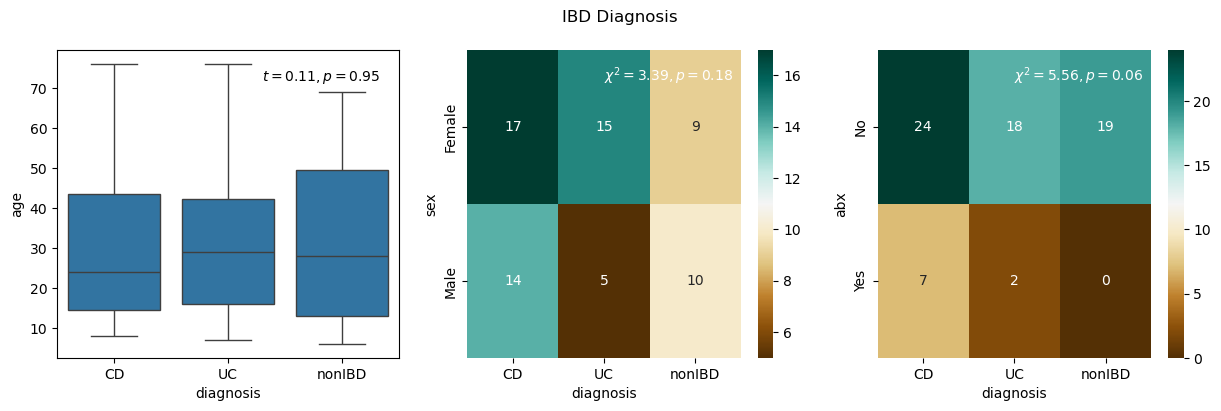

In [15]:
fig, axs = plt.subplots(1, 3, figsize = (15, 4))
fig.suptitle('IBD Diagnosis')

fig1 = sns.boxplot(x = 'diagnosis', y = 'age', data = smd, ax = axs[0])
t, p = stats.kruskal(smd.loc[smd['diagnosis'] == 'CD', 'age'],
                     smd.loc[smd['diagnosis'] == 'UC', 'age'],
                     smd.loc[smd['diagnosis'] == 'nonIBD', 'age'])
plt.text(0.6, 0.9, f'$t = {t:.2f}, p = {p:.2f}$', transform = axs[0].transAxes)

crosstab = pd.crosstab(smd['sex'], smd['diagnosis'])
fig2 = sns.heatmap(crosstab, annot = True, fmt='d', cmap = 'BrBG', ax = axs[1])
t, p, _, _ = stats.chi2_contingency(crosstab)
plt.text(0.5, 0.9, f'$\\chi^2 = {t:.2f}, p = {p:.2f}$', color = 'white', transform = axs[1].transAxes)

crosstab = pd.crosstab(smd['abx'], smd['diagnosis'])
fig3 = sns.heatmap(crosstab, annot = True, fmt='d', cmap = 'BrBG', ax = axs[2])
t, p, _, _ = stats.chi2_contingency(crosstab)
plt.text(0.5, 0.9, f'$\\chi^2 = {t:.2f}, p = {p:.2f}$', color = 'white', transform = axs[2].transAxes)

plt.show()

## Run MetVAE

### Data pre-processing

In [16]:
# CD cases
smd_cd = smd[smd['diagnosis'] == 'CD']
data_cd = abundance_data[smd_cd.index].T
# Calculate the proportion of zeros in each column
proportion_zeros = (data_cd == 0).mean()
data_cd = data_cd.loc[:, proportion_zeros <= 0.3]
n, d = data_cd.shape

print('# CD cases:', n)
print('# metabolites:', d)
print('Proportion of zeros: ', np.round((data_cd == 0).sum().sum()/data_cd.size*100), '%')

# CD cases: 31
# metabolites: 431
Proportion of zeros:  3.0 %


In [17]:
# UC cases
smd_uc = smd[smd['diagnosis'] == 'UC']
data_uc = abundance_data[smd_uc.index].T
# Calculate the proportion of zeros in each column
proportion_zeros = (data_uc == 0).mean()
data_uc = data_uc.loc[:, proportion_zeros <= 0.3]
n, d = data_uc.shape

print('# UC cases:', n)
print('# metabolites:', d)
print('Proportion of zeros: ', np.round((data_uc == 0).sum().sum()/data_uc.size*100), '%')

# UC cases: 20
# metabolites: 431
Proportion of zeros:  2.0 %


In [18]:
# Non-IBD controls
smd_ctrl = smd[smd['diagnosis'] == 'nonIBD']
data_ctrl = abundance_data[smd_ctrl.index].T
# Calculate the proportion of zeros in each column
proportion_zeros = (data_ctrl == 0).mean()
data_ctrl = data_ctrl.loc[:, proportion_zeros <= 0.3]
n, d = data_ctrl.shape

print('# Non-IBD controls:', n)
print('# metabolites:', d)
print('Proportion of zeros: ', np.round((data_ctrl == 0).sum().sum()/data_ctrl.size*100), '%')

# Non-IBD controls: 19
# metabolites: 420
Proportion of zeros:  3.0 %


In [19]:
# Subset to the overlapped features
overlap_features = list(set(data_cd.columns).intersection(data_uc.columns).intersection(data_ctrl.columns))
overlap_features.sort()
data_cd = data_cd.loc[:, overlap_features]
data_uc = data_uc.loc[:, overlap_features]
data_ctrl = data_ctrl.loc[:, overlap_features]

print('After preprocessing:')
print('# CD cases:', data_cd.shape[0])
print('# UC cases:', data_uc.shape[0])
print('# Non-IBD controls:', data_ctrl.shape[0])
print('# metabolites:', len(overlap_features))
print('Proportion of zeros in CD cases: ', np.round((data_cd == 0).sum().sum()/data_cd.size*100), '%')
print('Proportion of zeros in UC cases: ', np.round((data_uc == 0).sum().sum()/data_uc.size*100), '%')
print('Proportion of zeros in non-IBD controls: ', np.round((data_ctrl == 0).sum().sum()/data_ctrl.size*100), '%')

After preprocessing:
# CD cases: 31
# UC cases: 20
# Non-IBD controls: 19
# metabolites: 410
Proportion of zeros in CD cases:  2.0 %
Proportion of zeros in UC cases:  2.0 %
Proportion of zeros in non-IBD controls:  2.0 %


### CD cases

In [20]:
max_epochs=1000
learning_rate=1e-2

model = MetVAE(data=data_cd,
               features_as_rows=False,
               meta=smd_cd,
               continuous_covariate_keys=['age'],
               categorical_covariate_keys=['sex', 'abx'],
               latent_dim=data_cd.shape[0],
               use_gpu=False,
               seed=0)

model.train(batch_size=100,
            num_workers=0,
            max_epochs=max_epochs,
            learning_rate=learning_rate,
            log_every_n_steps=1)

Start: samples=31, features=410
Filtered features: removed 0 (threshold 0.30)
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=31, features=410
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=31, features=410


100%|██████████| 1000/1000 [00:02<00:00, 361.85it/s]


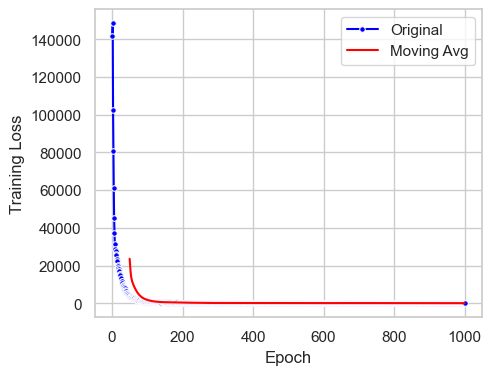

In [21]:
df_loss = pd.DataFrame({
    'Epoch': range(1, max_epochs+1),
    'Training Loss': model.train_loss
})
window_size = 50
df_loss['MA Training Loss'] = df_loss['Training Loss'].rolling(window=window_size).mean()
df_loss.replace([np.inf, -np.inf], np.nan, inplace=True)

plt.figure(figsize=(5, 4))
sns.set_theme(style="whitegrid")   
sns.lineplot(data=df_loss, x='Epoch', y='Training Loss', marker='o', markersize=4, color='blue', label='Original')
sns.lineplot(data=df_loss, x='Epoch', y='MA Training Loss', color='red', label='Moving Avg')
plt.show()

In [22]:
model.get_corr(num_sim=100, workers=-1, seed=0)
results_metvae = model.sparse_by_sec(c_grid = tuple(float(x)*0.01 for x in range(1, 10)))
print('rho = ', results_metvae['best_rho'])

rho =  0.005873777293802929


In [23]:
est_cor_cd = results_metvae['sparse_estimate'].values

df_cor_cd = pd.DataFrame(
    est_cor_cd,
    index=data_cd.columns,
    columns=data_cd.columns
)
df_cor_cd.head()

,C18n_QI06,C18n_QI07,C18n_QI08,C18n_QI10,C18n_QI11,C18n_QI12,C18n_QI13,C18n_QI14,C18n_QI15,C18n_QI16,...,HILp_TF51,HILp_TF53,HILp_TF54,HILp_TF55,HILp_TF56,HILp_TF57,HILp_TF58,HILp_TF7,HILp_TF8,HILp_TF9
C18n_QI06,1.00000,0.47791,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
C18n_QI07,0.47791,1.00000,0.000000,0.000000,0.0,0.000000,0.000000,0.142506,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
C18n_QI08,0.00000,0.00000,1.000000,0.276796,0.0,0.000000,0.271798,0.264339,0.262125,0.486484,...,0.000000,0.0,0.0,-0.123401,0.0,0.0,-0.173468,0.000000,0.297871,0.200077
C18n_QI10,0.00000,0.00000,0.276796,1.000000,0.0,0.000000,0.000000,0.331432,0.000000,0.438536,...,0.315418,0.0,0.0,0.000000,0.0,0.0,0.000000,0.103161,0.489259,0.264017
C18n_QI11,0.00000,0.00000,0.000000,0.000000,1.0,0.161764,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,-0.107975,0.0,0.0,0.000000,0.000000,0.000000,0.000000


### UC cases

In [24]:
max_epochs=1000
learning_rate=1e-2

model = MetVAE(data=data_uc,
               features_as_rows=False,
               meta=smd_uc,
               continuous_covariate_keys=['age'],
               categorical_covariate_keys=['sex', 'abx'],
               latent_dim=data_uc.shape[0],
               use_gpu=False,
               seed=0)

model.train(batch_size=100,
            num_workers=0,
            max_epochs=max_epochs,
            learning_rate=learning_rate,
            log_every_n_steps=1)

Start: samples=20, features=410
Filtered features: removed 0 (threshold 0.30)
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=20, features=410
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=20, features=410


100%|██████████| 1000/1000 [00:02<00:00, 470.16it/s]


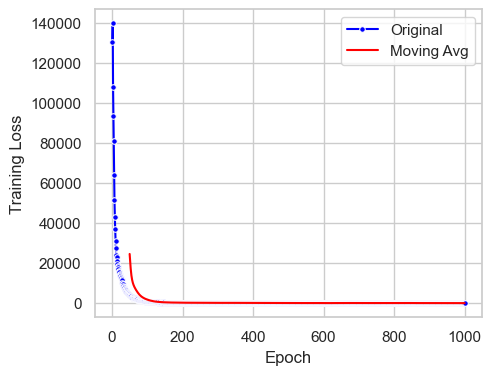

In [25]:
df_loss = pd.DataFrame({
    'Epoch': range(1, max_epochs+1),
    'Training Loss': model.train_loss
})
window_size = 50
df_loss['MA Training Loss'] = df_loss['Training Loss'].rolling(window=window_size).mean()
df_loss.replace([np.inf, -np.inf], np.nan, inplace=True)

plt.figure(figsize=(5, 4))
sns.set_theme(style="whitegrid")   
sns.lineplot(data=df_loss, x='Epoch', y='Training Loss', marker='o', markersize=4, color='blue', label='Original')
sns.lineplot(data=df_loss, x='Epoch', y='MA Training Loss', color='red', label='Moving Avg')
plt.show()

In [26]:
model.get_corr(num_sim=100, workers=-1, seed=0)
results_metvae = model.sparse_by_sec(c_grid = tuple(float(x) for x in range(1, 5)))
print('rho = ', results_metvae['best_rho'])

rho =  0.7312793756879242


In [27]:
est_cor_uc = results_metvae['sparse_estimate'].values

df_cor_uc = pd.DataFrame(
    est_cor_uc,
    index=data_uc.columns,
    columns=data_uc.columns
)
df_cor_uc.head()

,C18n_QI06,C18n_QI07,C18n_QI08,C18n_QI10,C18n_QI11,C18n_QI12,C18n_QI13,C18n_QI14,C18n_QI15,C18n_QI16,...,HILp_TF51,HILp_TF53,HILp_TF54,HILp_TF55,HILp_TF56,HILp_TF57,HILp_TF58,HILp_TF7,HILp_TF8,HILp_TF9
C18n_QI06,1.000000,0.847947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,-0.166295,-0.216662,0.0,0.0,0.0,0.0,0.0
C18n_QI07,0.847947,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,-0.193809,-0.270747,0.0,0.0,0.0,0.0,0.0
C18n_QI08,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.139257,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
C18n_QI10,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
C18n_QI11,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


### Non-IBD controls

In [28]:
max_epochs=1000
learning_rate=1e-2

model = MetVAE(data=data_ctrl,
               features_as_rows=False,
               meta=smd_ctrl,
               continuous_covariate_keys=['age'],
               categorical_covariate_keys=['sex', 'abx'],
               latent_dim=data_ctrl.shape[0],
               use_gpu=False,
               seed=0)

model.train(batch_size=100,
            num_workers=0,
            max_epochs=max_epochs,
            learning_rate=learning_rate,
            log_every_n_steps=1)

Start: samples=19, features=410
Filtered features: removed 0 (threshold 0.30)
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=19, features=410
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=19, features=410


100%|██████████| 1000/1000 [00:02<00:00, 438.92it/s]


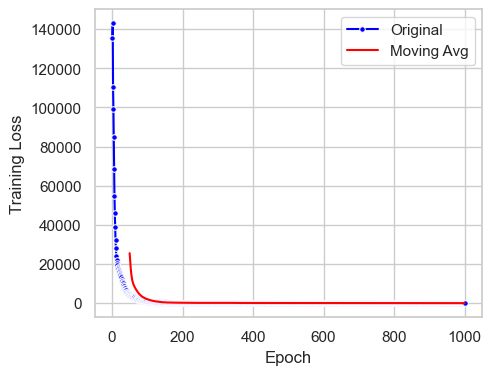

In [29]:
df_loss = pd.DataFrame({
    'Epoch': range(1, max_epochs+1),
    'Training Loss': model.train_loss
})
window_size = 50
df_loss['MA Training Loss'] = df_loss['Training Loss'].rolling(window=window_size).mean()
df_loss.replace([np.inf, -np.inf], np.nan, inplace=True)

plt.figure(figsize=(5, 4))
sns.set_theme(style="whitegrid")   
sns.lineplot(data=df_loss, x='Epoch', y='Training Loss', marker='o', markersize=4, color='blue', label='Original')
sns.lineplot(data=df_loss, x='Epoch', y='MA Training Loss', color='red', label='Moving Avg')
plt.show()

In [30]:
model.get_corr(num_sim=100, workers=-1, seed=0)
results_metvae = model.sparse_by_sec(c_grid = tuple(float(x) for x in range(1, 10)))
print('rho = ', results_metvae['best_rho'])

rho =  0.937846010977696


In [31]:
est_cor_ctrl = results_metvae['sparse_estimate'].values

df_cor_ctrl = pd.DataFrame(
    est_cor_ctrl,
    index=data_ctrl.columns,
    columns=data_ctrl.columns
)
df_cor_ctrl.head()

,C18n_QI06,C18n_QI07,C18n_QI08,C18n_QI10,C18n_QI11,C18n_QI12,C18n_QI13,C18n_QI14,C18n_QI15,C18n_QI16,...,HILp_TF51,HILp_TF53,HILp_TF54,HILp_TF55,HILp_TF56,HILp_TF57,HILp_TF58,HILp_TF7,HILp_TF8,HILp_TF9
C18n_QI06,1.000000,0.970428,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C18n_QI07,0.970428,1.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C18n_QI08,0.000000,0.000000,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C18n_QI10,0.000000,0.000000,0.0,1.000000,0.172366,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C18n_QI11,0.000000,0.000000,0.0,0.172366,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Visualizations

In [32]:
def add_cluster_rectangle(ax, row_idx, col_idx=None, color="red", linewidth=2, padding=0.0, **kwargs):
    """
    Draw a rectangle over a heatmap region.
    - row_idx: iterable of row indices (y-axis, e.g. [r0, r1, ..., rK])
    - col_idx: iterable of col indices (x-axis). If None, uses row_idx (diagonal square).
    - padding: expand rectangle by this many data units on all sides (e.g., 0.2)
    """
    if col_idx is None:
        col_idx = row_idx

    r0, r1 = min(row_idx), max(row_idx) + 1   # rows are y
    c0, c1 = min(col_idx), max(col_idx) + 1   # cols are x

    # Heatmap cells are centered on integers; edges sit at i±0.5
    x = c0 - 0.5 - padding
    y = r0 - 0.5 - padding
    w = (c1 - c0) + 2*padding
    h = (r1 - r0) + 2*padding

    rect = plt.Rectangle(
        (x, y), w, h,
        fill=False,
        edgecolor=color,
        lw=linewidth,
        clip_on=False,
        zorder=10,
        **kwargs
    )
    ax.add_patch(rect)
    return rect


In [33]:
# Start and end indices for the first cluster
start_idx = overlap_features.index("C8p_QI214")
end_idx = overlap_features.index("C8p_QI43") + 1 
cluster1 = overlap_features[start_idx:end_idx]

# Start and end indices for the second cluster
start_idx = overlap_features.index("C8p_QI62")
end_idx = overlap_features.index("C8p_QI86") + 1  
cluster2 = overlap_features[start_idx:end_idx]

# Start and end indices for the third cluster
start_idx = overlap_features.index("C8p_QI62")
end_idx = overlap_features.index("C8p_QI86") + 1 
cluster3_row = overlap_features[start_idx:end_idx]

start_idx = overlap_features.index("C8p_QI174")
end_idx = overlap_features.index("C8p_QI209") + 1 
cluster3_col = overlap_features[start_idx:end_idx]

#### Heatmap: All features

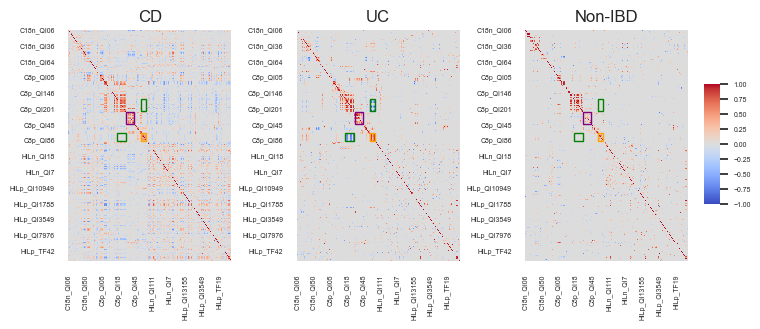

In [34]:
# Create subplots
fig_all, axs = plt.subplots(1, 3, figsize=(8, 3), gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.4})

# Shared colorbar axis
cbar_ax = fig_all.add_axes([0.92, 0.3, 0.02, 0.4])
cbar_ax.tick_params(labelsize=5)

# Plot heatmaps and add rectangles for clusters
for ax, data, title in zip(axs, [df_cor_cd, df_cor_uc, df_cor_ctrl], ['CD', 'UC', 'Non-IBD']):
    sns.heatmap(data, cmap='coolwarm', cbar=ax == axs[0], vmin=-1, vmax=1,
                ax=ax, cbar_ax=cbar_ax if ax == axs[0] else None)
    ax.set_title(title)

    # Indices for cluster 1 & 2 (square on diagonal)
    cluster1_indices = [overlap_features.index(feat) for feat in cluster1]
    cluster2_indices = [overlap_features.index(feat) for feat in cluster2]

    # Indices for cluster 3 (off-diagonal: separate rows & cols)
    cluster3_row_idx = [overlap_features.index(feat) for feat in cluster3_row]
    cluster3_col_idx = [overlap_features.index(feat) for feat in cluster3_col]

    # Draw rectangles
    add_cluster_rectangle(ax, cluster1_indices, color='purple', linewidth=1)
    add_cluster_rectangle(ax, cluster2_indices, color='orange', linewidth=1)
    add_cluster_rectangle(ax, cluster3_row_idx, col_idx=cluster3_col_idx, color='green', linewidth=1)
    add_cluster_rectangle(ax, cluster3_col_idx, col_idx=cluster3_row_idx, color='green', linewidth=1)

    ax.tick_params(axis='both', which='major', labelsize=5)

plt.show()

#### Heatmap: Zoom-in view of the clusters

In [35]:
start_idx = overlap_features.index("C8p_QI151")
end_idx = overlap_features.index("C8p_QI98") + 1  
sub_features = overlap_features[start_idx:end_idx]

# Subset correlation matrices to metabolites of interest
df_cor_cd_subset = df_cor_cd.loc[sub_features, sub_features]
df_cor_uc_subset = df_cor_uc.loc[sub_features, sub_features]
df_cor_ctrl_subset = df_cor_ctrl.loc[sub_features, sub_features]

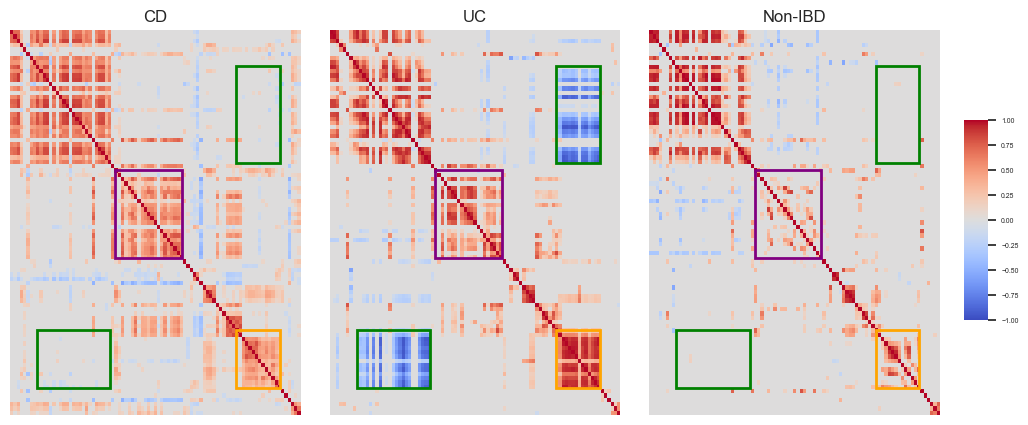

In [36]:
# Create subplots
fig_sub, axs = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.1})

# Create a shared color bar axis
cbar_ax = fig_sub.add_axes([0.92, 0.3, 0.02, 0.4])
cbar_ax.tick_params(labelsize=5)

# Plot heatmaps and add rectangles for clusters
for ax, data, title in zip(axs, [df_cor_cd_subset, df_cor_uc_subset, df_cor_ctrl_subset], ['CD', 'UC', 'Non-IBD']):
    sns.heatmap(data, cmap='coolwarm', cbar=ax == axs[0], vmin=-1, vmax=1, ax=ax, cbar_ax=cbar_ax if ax == axs[0] else None)
    ax.set_title(title)

    # Indices for cluster 1 & 2 (square on diagonal)
    cluster1_indices = [sub_features.index(feat) for feat in cluster1]
    cluster2_indices = [sub_features.index(feat) for feat in cluster2]

    # Indices for cluster 3 (off-diagonal: separate rows & cols)
    cluster3_row_idx = [sub_features.index(feat) for feat in cluster3_row]
    cluster3_col_idx = [sub_features.index(feat) for feat in cluster3_col]

    # Draw rectangles
    add_cluster_rectangle(ax, cluster1_indices, color='purple', linewidth=2, padding=0.2)
    add_cluster_rectangle(ax, cluster2_indices, color='orange', linewidth=2, padding=0.2)
    add_cluster_rectangle(ax, cluster3_row_idx, col_idx=cluster3_col_idx, color='green', linewidth=2, padding=0.2)
    add_cluster_rectangle(ax, cluster3_col_idx, col_idx=cluster3_row_idx, color='green', linewidth=2, padding=0.2)

    # Remove ticks and labels
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis='x', bottom=False)
    ax.tick_params(axis='y', left=False)

plt.show()

#### Venn diagram

In [37]:
def extract_lower_triangle(corr_matrix):
    rows, cols = np.tril_indices(corr_matrix.shape[0], -1)
    df = pd.DataFrame({
        'feature1': corr_matrix.index[rows],
        'feature2': corr_matrix.columns[cols],
        'value': corr_matrix.values[rows, cols]
    })
    return df

df_cor_cd_long = extract_lower_triangle(df_cor_cd)
df_cor_uc_long = extract_lower_triangle(df_cor_uc)
df_cor_ctrl_long = extract_lower_triangle(df_cor_ctrl)

In [38]:
df_cor_cd_long = df_cor_cd_long.rename(columns={'value': 'value_cd'})
df_cor_uc_long = df_cor_uc_long.rename(columns={'value': 'value_uc'})
df_cor_ctrl_long = df_cor_ctrl_long.rename(columns={'value': 'value_ctrl'})

merge_df = pd.merge(df_cor_cd_long, df_cor_uc_long, on=['feature1', 'feature2'])
merge_df = pd.merge(merge_df, df_cor_ctrl_long, on=['feature1', 'feature2'])

In [39]:
# Positive correlations
df_cor_cd_pos = df_cor_cd_long[df_cor_cd_long['value_cd'] > 0]
df_cor_uc_pos = df_cor_uc_long[df_cor_uc_long['value_uc'] > 0]
df_cor_ctrl_pos = df_cor_ctrl_long[df_cor_ctrl_long['value_ctrl'] > 0]

set_cd_pos = set(zip(df_cor_cd_pos['feature1'], df_cor_cd_pos['feature2']))
set_uc_pos = set(zip(df_cor_uc_pos['feature1'], df_cor_uc_pos['feature2']))
set_ctrl_pos = set(zip(df_cor_ctrl_pos['feature1'], df_cor_ctrl_pos['feature2']))

In [40]:
# Negative correlations
df_cor_cd_neg = df_cor_cd_long[df_cor_cd_long['value_cd'] < 0]
df_cor_uc_neg = df_cor_uc_long[df_cor_uc_long['value_uc'] < 0]
df_cor_ctrl_neg = df_cor_ctrl_long[df_cor_ctrl_long['value_ctrl'] < 0]

set_cd_neg = set(zip(df_cor_cd_neg['feature1'], df_cor_cd_neg['feature2']))
set_uc_neg = set(zip(df_cor_uc_neg['feature1'], df_cor_uc_neg['feature2']))
set_ctrl_neg = set(zip(df_cor_ctrl_neg['feature1'], df_cor_ctrl_neg['feature2']))

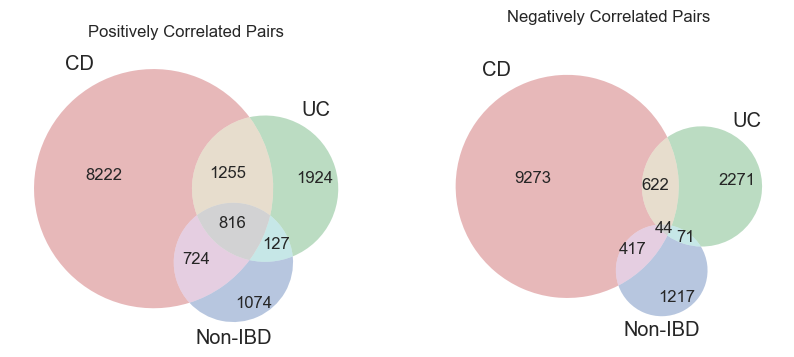

In [41]:
fig_venn, axs = plt.subplots(1, 2, figsize=(10, 6))

matplotlib_venn.venn3([set_cd_pos, set_uc_pos, set_ctrl_pos], ('CD', 'UC', 'Non-IBD'), ax=axs[0])
axs[0].set_title("Positively Correlated Pairs")

matplotlib_venn.venn3([set_cd_neg, set_uc_neg, set_ctrl_neg], ('CD', 'UC', 'Non-IBD'), ax=axs[1])
axs[1].set_title("Negatively Correlated Pairs", pad=22)

plt.show()

## Other Methods

### Pearson's correlation

In [42]:
def calculate_pearson_correlation(data, threshold=0.005):
    d = data.shape[1]
    corr_matrix = np.zeros((d, d))
    p_matrix = np.zeros((d, d))
    
    # Compute correlations and p-values for each pair
    for i in range(d):
        for j in range(d):
            if i == j:
                corr_matrix[i, j] = 1.0  # Diagonal correlations are 1
                p_matrix[i, j] = 0.0    # Diagonal p-values are 0
            elif i < j:
                corr, p_value = stats.pearsonr(data.iloc[:, i], data.iloc[:, j])
                corr_matrix[i, j] = corr
                p_matrix[i, j] = p_value
                corr_matrix[j, i] = corr
                p_matrix[j, i] = p_value
    
    # Zero out correlations with p-values >= threshold
    corr_matrix[p_matrix >= threshold] = 0
    
    return corr_matrix

In [43]:
pearson_corr_cd = calculate_pearson_correlation(data_cd)
pearson_corr_uc = calculate_pearson_correlation(data_uc)
pearson_corr_ctrl = calculate_pearson_correlation(data_ctrl)

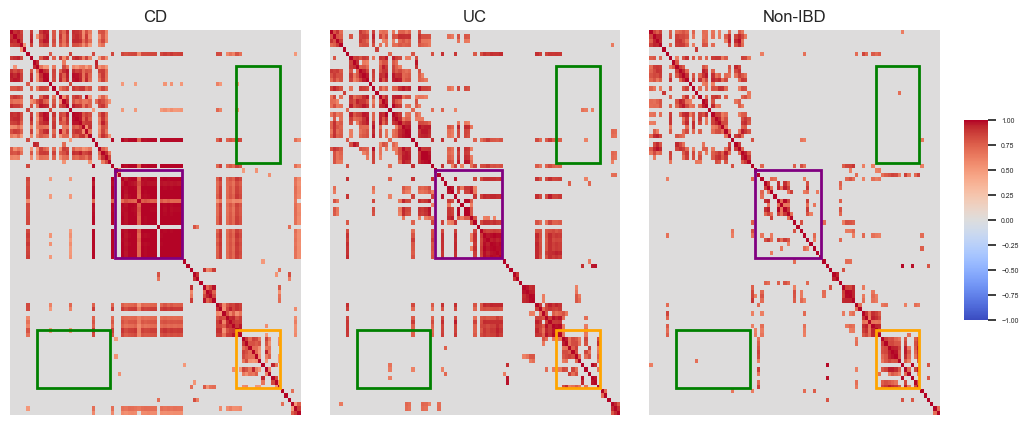

In [44]:
# Subset correlation matrices to metabolites of interest
pearson_corr_cd = pd.DataFrame(pearson_corr_cd, index=overlap_features, columns=overlap_features)
pearson_corr_uc = pd.DataFrame(pearson_corr_uc, index=overlap_features, columns=overlap_features)
pearson_corr_ctrl = pd.DataFrame(pearson_corr_ctrl, index=overlap_features, columns=overlap_features)
pearson_corr_cd_subset = pearson_corr_cd.loc[sub_features, sub_features]
pearson_corr_uc_subset = pearson_corr_uc.loc[sub_features, sub_features]
pearson_corr_ctrl_subset = pearson_corr_ctrl.loc[sub_features, sub_features]

# Create subplots
fig_pearson, axs = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.1})

# Create a shared color bar axis
cbar_ax = fig_pearson.add_axes([0.92, 0.3, 0.02, 0.4])
cbar_ax.tick_params(labelsize=5)

# Plot heatmaps and add rectangles for clusters
for ax, data, title in zip(axs, [pearson_corr_cd_subset, pearson_corr_uc_subset, pearson_corr_ctrl_subset], ['CD', 'UC', 'Non-IBD']):
    sns.heatmap(data, cmap='coolwarm', cbar=ax == axs[0], vmin=-1, vmax=1, ax=ax, cbar_ax=cbar_ax if ax == axs[0] else None)
    ax.set_title(title)

    # Indices for cluster 1 & 2 (square on diagonal)
    cluster1_indices = [sub_features.index(feat) for feat in cluster1]
    cluster2_indices = [sub_features.index(feat) for feat in cluster2]

    # Indices for cluster 3 (off-diagonal: separate rows & cols)
    cluster3_row_idx = [sub_features.index(feat) for feat in cluster3_row]
    cluster3_col_idx = [sub_features.index(feat) for feat in cluster3_col]

    # Draw rectangles
    add_cluster_rectangle(ax, cluster1_indices, color='purple', linewidth=2, padding=0.2)
    add_cluster_rectangle(ax, cluster2_indices, color='orange', linewidth=2, padding=0.2)
    add_cluster_rectangle(ax, cluster3_row_idx, col_idx=cluster3_col_idx, color='green', linewidth=2, padding=0.2)
    add_cluster_rectangle(ax, cluster3_col_idx, col_idx=cluster3_row_idx, color='green', linewidth=2, padding=0.2)

    # Remove ticks and labels
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis='x', bottom=False)
    ax.tick_params(axis='y', left=False)

plt.show()

### Spearman's correlation

In [45]:
def calculate_spearman_correlation(data, threshold=0.005):
    d = data.shape[1]
    corr_matrix = np.zeros((d, d))
    p_matrix = np.zeros((d, d))
    
    # Compute correlations and p-values for each pair
    for i in range(d):
        for j in range(d):
            if i == j:
                corr_matrix[i, j] = 1.0  # Diagonal correlations are 1
                p_matrix[i, j] = 0.0    # Diagonal p-values are 0
            elif i < j:
                corr, p_value = stats.spearmanr(data.iloc[:, i], data.iloc[:, j])
                corr_matrix[i, j] = corr
                p_matrix[i, j] = p_value
                corr_matrix[j, i] = corr
                p_matrix[j, i] = p_value
    
    # Zero out correlations with p-values >= threshold
    corr_matrix[p_matrix >= threshold] = 0
    
    return corr_matrix

In [46]:
spearman_corr_cd = calculate_spearman_correlation(data_cd)
spearman_corr_uc = calculate_spearman_correlation(data_uc)
spearman_corr_ctrl = calculate_spearman_correlation(data_ctrl)

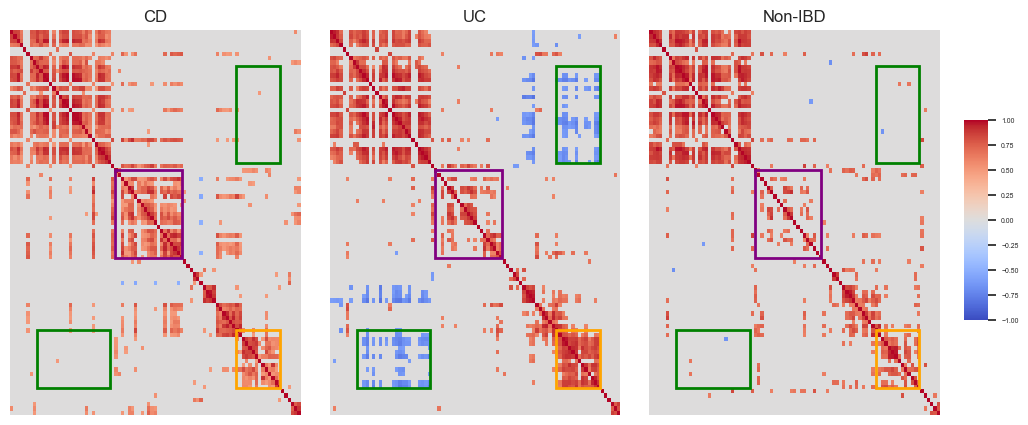

In [47]:
# Subset correlation matrices to metabolites of interest
spearman_corr_cd = pd.DataFrame(spearman_corr_cd, index=overlap_features, columns=overlap_features)
spearman_corr_uc = pd.DataFrame(spearman_corr_uc, index=overlap_features, columns=overlap_features)
spearman_corr_ctrl = pd.DataFrame(spearman_corr_ctrl, index=overlap_features, columns=overlap_features)
spearman_corr_cd_subset = spearman_corr_cd.loc[sub_features, sub_features]
spearman_corr_uc_subset = spearman_corr_uc.loc[sub_features, sub_features]
spearman_corr_ctrl_subset = spearman_corr_ctrl.loc[sub_features, sub_features]

# Create subplots
fig_spearman, axs = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.1})

# Create a shared color bar axis
cbar_ax = fig_spearman.add_axes([0.92, 0.3, 0.02, 0.4])
cbar_ax.tick_params(labelsize=5)

# Plot heatmaps and add rectangles for clusters
for ax, data, title in zip(axs, [spearman_corr_cd_subset, spearman_corr_uc_subset, spearman_corr_ctrl_subset], ['CD', 'UC', 'Non-IBD']):
    sns.heatmap(data, cmap='coolwarm', cbar=ax == axs[0], vmin=-1, vmax=1, ax=ax, cbar_ax=cbar_ax if ax == axs[0] else None)
    ax.set_title(title)

    # Indices for cluster 1 & 2 (square on diagonal)
    cluster1_indices = [sub_features.index(feat) for feat in cluster1]
    cluster2_indices = [sub_features.index(feat) for feat in cluster2]

    # Indices for cluster 3 (off-diagonal: separate rows & cols)
    cluster3_row_idx = [sub_features.index(feat) for feat in cluster3_row]
    cluster3_col_idx = [sub_features.index(feat) for feat in cluster3_col]

    # Draw rectangles
    add_cluster_rectangle(ax, cluster1_indices, color='purple', linewidth=2, padding=0.2)
    add_cluster_rectangle(ax, cluster2_indices, color='orange', linewidth=2, padding=0.2)
    add_cluster_rectangle(ax, cluster3_row_idx, col_idx=cluster3_col_idx, color='green', linewidth=2, padding=0.2)
    add_cluster_rectangle(ax, cluster3_col_idx, col_idx=cluster3_row_idx, color='green', linewidth=2, padding=0.2)

    # Remove ticks and labels
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis='x', bottom=False)
    ax.tick_params(axis='y', left=False)

plt.show()

## Outputs

In [48]:
abundance_data.to_csv('../results/intermediate_results/ibd_abundance_clean.csv')
fmd.to_csv('../results/intermediate_results/ibd_fmd_clean.csv')
smd.to_csv('../results/intermediate_results/ibd_smd_clean.csv')
fmd.loc[sub_features, ].to_csv('../results/intermediate_results/ibd_cluster_hmdb.csv')

In [49]:
df1 = fmd.loc[cluster1].copy()        
df2 = fmd.loc[cluster2].copy()
df3 = fmd.loc[cluster3_col].copy()

df1["Cluster"] = "Cluster1"
df2["Cluster"] = "Cluster2"
df3["Cluster"] = "Cluster3"

fmd_cluster = pd.concat([df1, df2, df3], axis=0)
fmd_cluster.to_csv('../results/outputs/ibd_cluster.csv')

In [50]:
output_file = '../results/outputs/ibd_corr.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_cor_cd.to_excel(writer, sheet_name='cd', index=False)
    df_cor_uc.to_excel(writer, sheet_name='uc', index=False)
    df_cor_ctrl.to_excel(writer, sheet_name='ctrl', index=False)

In [51]:
fig_all.savefig("../results/figures/supp_ibd_heat.pdf", bbox_inches="tight")
fig_sub.savefig("../results/figures/main_ibd_heat.pdf", bbox_inches="tight")
fig_venn.savefig("../results/figures/ext_ibd_venn.pdf", bbox_inches="tight")
fig_pearson.savefig('../results/figures/ext_ibd_pearson.pdf', bbox_inches='tight')
fig_spearman.savefig('../results/figures/ext_ibd_spearman.pdf', bbox_inches='tight')